# Principal Components Analysis Nutrition Exercise
En este ejercicio no vas a montar ningún modelo de Machine Learning supervisado, sino aprenderás a trabajar con PCA: pretratar el dato antes de calcular sus PCs, interpretarlos, graficar y escoger número de componentes según varianza.

Importa las librerías necesarias

In [1]:
# las librerías

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# importaciones de
# PCA
# StandardScaler


from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


### Importa los datos
1. Importa los datos: *nndb.csv*
2. Observa las columnas que hay, así como su tipo.

In [3]:
df = pd.read_csv("nndb_flat.csv")
df

,ID,FoodGroup,ShortDescrip,Descrip,CommonName,MfgName,ScientificName,Energy_kcal,Protein_g,Fat_g,...,Folate_USRDA,Niacin_USRDA,Riboflavin_USRDA,Thiamin_USRDA,Calcium_USRDA,Copper_USRDA,Magnesium_USRDA,Phosphorus_USRDA,Selenium_USRDA,Zinc_USRDA
0,1001,Dairy and Egg Products,"BUTTER,WITH SALT","Butter, salted",NaN,NaN,NaN,717.0,0.85,81.11,...,0.0075,0.002625,0.026154,0.004167,0.020000,0.000000,0.004762,0.034286,0.018182,0.008182
1,1002,Dairy and Egg Products,"BUTTER,WHIPPED,WITH SALT","Butter, whipped, with salt",NaN,NaN,NaN,717.0,0.85,81.11,...,0.0075,0.002625,0.026154,0.004167,0.020000,0.000018,0.004762,0.032857,0.018182,0.004545
2,1003,Dairy and Egg Products,"BUTTER OIL,ANHYDROUS","Butter oil, anhydrous",NaN,NaN,NaN,876.0,0.28,99.48,...,0.0000,0.000188,0.003846,0.000833,0.003333,0.000001,0.000000,0.004286,0.000000,0.000909
3,1004,Dairy and Egg Products,"CHEESE,BLUE","Cheese, blue",NaN,NaN,NaN,353.0,21.40,28.74,...,0.0900,0.063500,0.293846,0.024167,0.440000,0.000044,0.054762,0.552857,0.263636,0.241818
4,1005,Dairy and Egg Products,"CHEESE,BRICK","Cheese, brick",NaN,NaN,NaN,371.0,23.24,29.68,...,0.0500,0.007375,0.270000,0.011667,0.561667,0.000027,0.057143,0.644286,0.263636,0.236364
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8613,83110,Finfish and Shellfish Products,"MACKEREL,SALTED","Fish, mackerel, salted",NaN,NaN,NaN,305.0,18.50,25.10,...,0.0375,0.206250,0.146154,0.016667,0.055000,0.000111,0.142857,0.362857,1.334545,0.100000
8614,90240,Finfish and Shellfish Products,"SCALLOP,(BAY&SEA),CKD,STMD","Mollusks, scallop, (bay and sea), cooked, steamed",NaN,NaN,NaN,111.0,20.54,0.84,...,0.0500,0.067250,0.018462,0.010000,0.008333,0.000037,0.088095,0.608571,0.394545,0.140909
8615,90480,Sweets,"SYRUP,CANE","Syrup, Cane",NaN,NaN,NaN,269.0,0.00,0.00,...,0.0000,0.006250,0.046154,0.108333,0.010833,0.000022,0.023810,0.011429,0.012727,0.017273
8616,90560,Finfish and Shellfish Products,"SNAIL,RAW","Mollusks, snail, raw",NaN,NaN,NaN,90.0,16.10,1.40,...,0.0150,0.087500,0.092308,0.008333,0.008333,0.000444,0.595238,0.388571,0.498182,0.090909


In [4]:
# info del df

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8618 entries, 0 to 8617
Data columns (total 45 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                8618 non-null   int64  
 1   FoodGroup         8618 non-null   str    
 2   ShortDescrip      8618 non-null   str    
 3   Descrip           8618 non-null   str    
 4   CommonName        1063 non-null   str    
 5   MfgName           1560 non-null   str    
 6   ScientificName    732 non-null    str    
 7   Energy_kcal       8618 non-null   float64
 8   Protein_g         8618 non-null   float64
 9   Fat_g             8618 non-null   float64
 10  Carb_g            8618 non-null   float64
 11  Sugar_g           8618 non-null   float64
 12  Fiber_g           8618 non-null   float64
 13  VitA_mcg          8618 non-null   float64
 14  VitB6_mg          8618 non-null   float64
 15  VitB12_mcg        8618 non-null   float64
 16  VitC_mg           8618 non-null   float64
 17  VitE_m

In [5]:
# describe del df

df.describe()

,ID,Energy_kcal,Protein_g,Fat_g,Carb_g,Sugar_g,Fiber_g,VitA_mcg,VitB6_mg,VitB12_mcg,...,Folate_USRDA,Niacin_USRDA,Riboflavin_USRDA,Thiamin_USRDA,Calcium_USRDA,Copper_USRDA,Magnesium_USRDA,Phosphorus_USRDA,Selenium_USRDA,Zinc_USRDA
count,8618.000000,8618.000000,8618.00000,8618.000000,8618.000000,8618.000000,8618.000000,8618.000000,8618.000000,8618.000000,...,8618.000000,8618.000000,8618.000000,8618.000000,8618.000000,8618.000000,8618.000000,8618.000000,8618.000000,8618.000000
mean,15467.757368,226.438617,11.52391,10.647024,21.819062,6.560253,2.023242,93.968786,0.264369,1.225260,...,0.125765,0.213222,0.182499,0.174881,0.061176,0.000191,0.077965,0.222838,0.229363,0.179111
std,9221.428766,169.388910,10.55059,15.866353,27.239000,13.602098,4.313670,779.362205,0.478614,4.319183,...,0.466402,0.302161,0.346062,0.431974,0.167803,0.000615,0.133496,0.290133,0.514406,0.305292
min,1001.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,8695.250000,93.000000,2.47000,0.992500,0.040000,0.000000,0.000000,0.000000,0.034250,0.000000,...,0.000000,0.023875,0.035385,0.025000,0.007500,0.000033,0.023810,0.052857,0.001818,0.020909
50%,14273.000000,191.000000,8.28500,5.235000,8.945000,0.370000,0.300000,1.500000,0.120000,0.080000,...,0.017500,0.131250,0.115385,0.064583,0.015833,0.000088,0.047619,0.190000,0.070909,0.076818
75%,20050.750000,336.000000,19.97750,13.900000,32.900000,5.300000,2.400000,21.000000,0.355000,1.297500,...,0.062500,0.314328,0.200000,0.185833,0.051667,0.000161,0.069048,0.308571,0.387273,0.245455
max,93600.000000,902.000000,88.32000,100.000000,100.000000,99.800000,79.000000,30000.000000,12.000000,98.890000,...,14.702500,7.968750,13.461538,19.479167,6.136667,0.016722,1.859524,14.168571,34.854545,8.268182


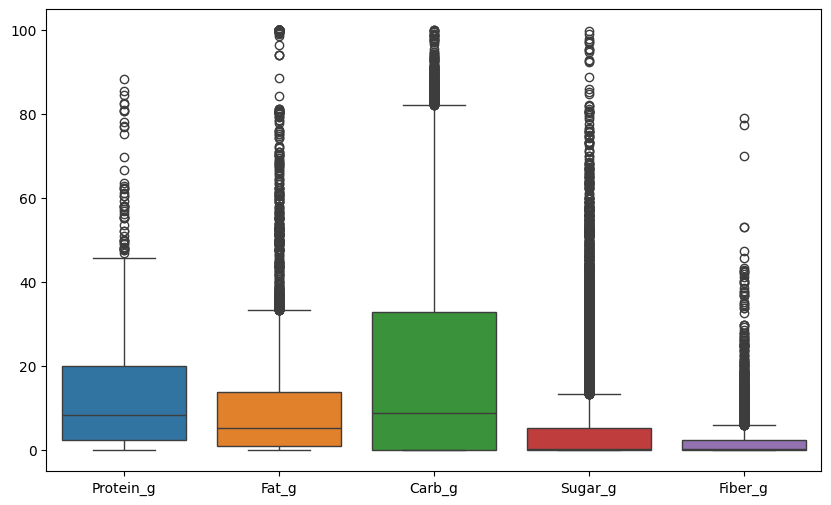

In [6]:
# boxplot de las columnas 8 a 13

plt.figure(figsize=(10,6))

sns.boxplot(data=df.iloc[:, 8:13])

plt.show()

### Mira a ver la correlación entre las variables numéricas
¿Qué pasa con las columnas USRDA? ¿Hay que tomar alguna decisión?

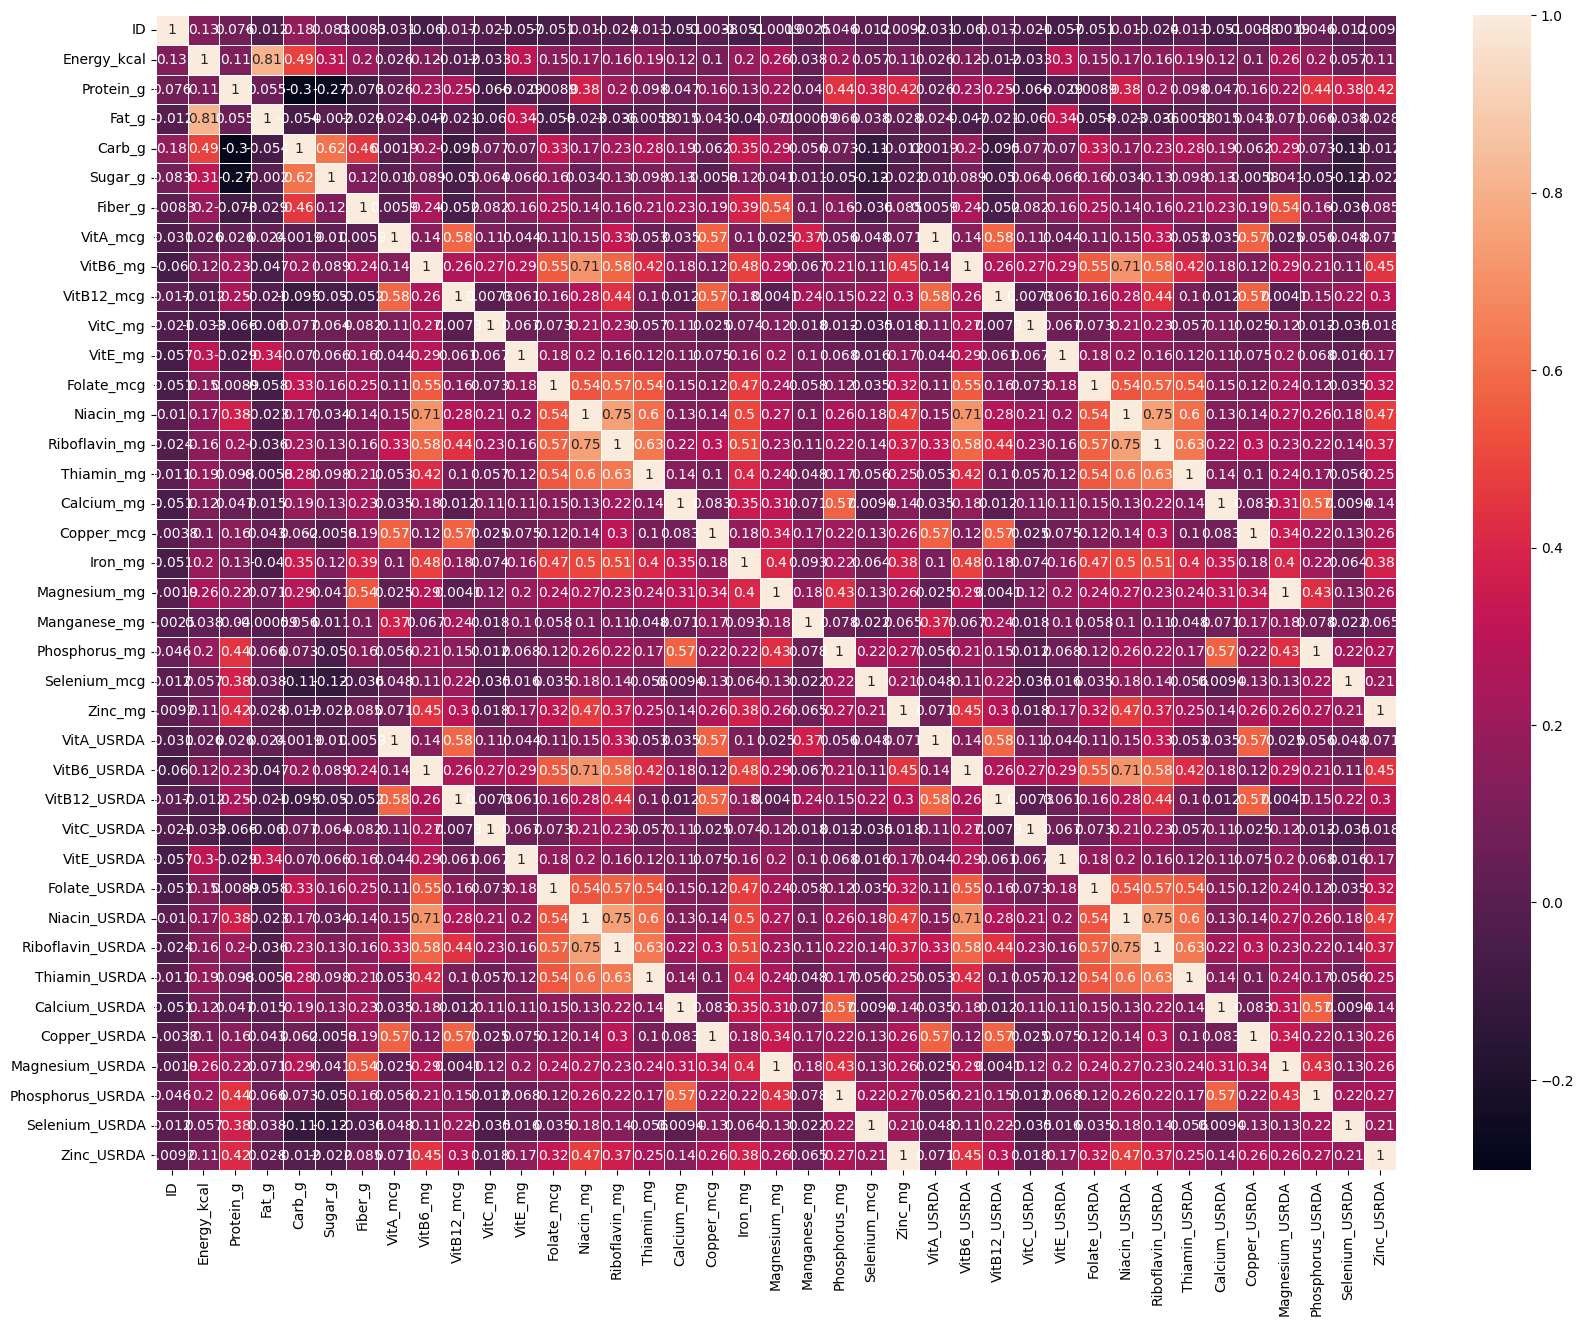

In [7]:
# heatmap para la correlación de Pearson con las columnas numéricas
plt.figure(figsize=(20,15))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    fmt=".2g",
    cmap="rocket",
    linewidths=0.5
)

plt.show()

*¿Qué pasa con las columnas USRDA? ¿Hay que tomar alguna decisión?*

No aportan información nutricional real, y pueden distorsionar PCA

In [8]:

# columnas que contienen USRDA en su nombre

df.columns[df.columns.str.contains("USRDA")]

Index(['VitA_USRDA', 'VitB6_USRDA', 'VitB12_USRDA', 'VitC_USRDA', 'VitE_USRDA',
       'Folate_USRDA', 'Niacin_USRDA', 'Riboflavin_USRDA', 'Thiamin_USRDA',
       'Calcium_USRDA', 'Copper_USRDA', 'Magnesium_USRDA', 'Phosphorus_USRDA',
       'Selenium_USRDA', 'Zinc_USRDA'],
      dtype='str')

In [9]:

# elimino las columnas que contienen USRDA por colinealidad

df = df.drop(columns=df.columns[df.columns.str.contains("USRDA")])

df.head()

,ID,FoodGroup,ShortDescrip,Descrip,CommonName,MfgName,ScientificName,Energy_kcal,Protein_g,Fat_g,...,Riboflavin_mg,Thiamin_mg,Calcium_mg,Copper_mcg,Iron_mg,Magnesium_mg,Manganese_mg,Phosphorus_mg,Selenium_mcg,Zinc_mg
0,1001,Dairy and Egg Products,"BUTTER,WITH SALT","Butter, salted",NaN,NaN,NaN,717.0,0.85,81.11,...,0.034,0.005,24.0,0.000,0.02,2.0,0.000,24.0,1.0,0.09
1,1002,Dairy and Egg Products,"BUTTER,WHIPPED,WITH SALT","Butter, whipped, with salt",NaN,NaN,NaN,717.0,0.85,81.11,...,0.034,0.005,24.0,0.016,0.16,2.0,0.004,23.0,1.0,0.05
2,1003,Dairy and Egg Products,"BUTTER OIL,ANHYDROUS","Butter oil, anhydrous",NaN,NaN,NaN,876.0,0.28,99.48,...,0.005,0.001,4.0,0.001,0.00,0.0,0.000,3.0,0.0,0.01
3,1004,Dairy and Egg Products,"CHEESE,BLUE","Cheese, blue",NaN,NaN,NaN,353.0,21.40,28.74,...,0.382,0.029,528.0,0.040,0.31,23.0,0.009,387.0,14.5,2.66
4,1005,Dairy and Egg Products,"CHEESE,BRICK","Cheese, brick",NaN,NaN,NaN,371.0,23.24,29.68,...,0.351,0.014,674.0,0.024,0.43,24.0,0.012,451.0,14.5,2.60


### Variables no numéricas
Elimina las variables de texto del dataset

In [10]:

# pongo el ID de índice

df = df.set_index("ID")

df.head()


,FoodGroup,ShortDescrip,Descrip,CommonName,MfgName,ScientificName,Energy_kcal,Protein_g,Fat_g,Carb_g,...,Riboflavin_mg,Thiamin_mg,Calcium_mg,Copper_mcg,Iron_mg,Magnesium_mg,Manganese_mg,Phosphorus_mg,Selenium_mcg,Zinc_mg
ID,,,,,,,,,,,,,,,,,,,,,
1001,Dairy and Egg Products,"BUTTER,WITH SALT","Butter, salted",NaN,NaN,NaN,717.0,0.85,81.11,0.06,...,0.034,0.005,24.0,0.000,0.02,2.0,0.000,24.0,1.0,0.09
1002,Dairy and Egg Products,"BUTTER,WHIPPED,WITH SALT","Butter, whipped, with salt",NaN,NaN,NaN,717.0,0.85,81.11,0.06,...,0.034,0.005,24.0,0.016,0.16,2.0,0.004,23.0,1.0,0.05
1003,Dairy and Egg Products,"BUTTER OIL,ANHYDROUS","Butter oil, anhydrous",NaN,NaN,NaN,876.0,0.28,99.48,0.00,...,0.005,0.001,4.0,0.001,0.00,0.0,0.000,3.0,0.0,0.01
1004,Dairy and Egg Products,"CHEESE,BLUE","Cheese, blue",NaN,NaN,NaN,353.0,21.40,28.74,2.34,...,0.382,0.029,528.0,0.040,0.31,23.0,0.009,387.0,14.5,2.66
1005,Dairy and Egg Products,"CHEESE,BRICK","Cheese, brick",NaN,NaN,NaN,371.0,23.24,29.68,2.79,...,0.351,0.014,674.0,0.024,0.43,24.0,0.012,451.0,14.5,2.60


In [11]:
# miro el dtypes

df.dtypes

FoodGroup             str
ShortDescrip          str
Descrip               str
CommonName            str
MfgName               str
ScientificName        str
Energy_kcal       float64
Protein_g         float64
Fat_g             float64
Carb_g            float64
Sugar_g           float64
Fiber_g           float64
VitA_mcg          float64
VitB6_mg          float64
VitB12_mcg        float64
VitC_mg           float64
VitE_mg           float64
Folate_mcg        float64
Niacin_mg         float64
Riboflavin_mg     float64
Thiamin_mg        float64
Calcium_mg        float64
Copper_mcg        float64
Iron_mg           float64
Magnesium_mg      float64
Manganese_mg      float64
Phosphorus_mg     float64
Selenium_mcg      float64
Zinc_mg           float64
dtype: object

In [12]:
# muestro todas las columnas numéricas

df.select_dtypes(include="number")

,Energy_kcal,Protein_g,Fat_g,Carb_g,Sugar_g,Fiber_g,VitA_mcg,VitB6_mg,VitB12_mcg,VitC_mg,...,Riboflavin_mg,Thiamin_mg,Calcium_mg,Copper_mcg,Iron_mg,Magnesium_mg,Manganese_mg,Phosphorus_mg,Selenium_mcg,Zinc_mg
ID,,,,,,,,,,,,,,,,,,,,,
1001,717.0,0.85,81.11,0.06,0.06,0.0,684.0,0.003,0.17,0.0,...,0.034,0.005,24.0,0.000,0.02,2.0,0.000,24.0,1.0,0.09
1002,717.0,0.85,81.11,0.06,0.06,0.0,684.0,0.003,0.13,0.0,...,0.034,0.005,24.0,0.016,0.16,2.0,0.004,23.0,1.0,0.05
1003,876.0,0.28,99.48,0.00,0.00,0.0,840.0,0.001,0.01,0.0,...,0.005,0.001,4.0,0.001,0.00,0.0,0.000,3.0,0.0,0.01
1004,353.0,21.40,28.74,2.34,0.50,0.0,198.0,0.166,1.22,0.0,...,0.382,0.029,528.0,0.040,0.31,23.0,0.009,387.0,14.5,2.66
1005,371.0,23.24,29.68,2.79,0.51,0.0,292.0,0.065,1.26,0.0,...,0.351,0.014,674.0,0.024,0.43,24.0,0.012,451.0,14.5,2.60
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83110,305.0,18.50,25.10,0.00,0.00,0.0,47.0,0.410,12.00,0.0,...,0.190,0.020,66.0,0.100,1.40,60.0,0.000,254.0,73.4,1.10
90240,111.0,20.54,0.84,5.41,0.00,0.0,2.0,0.112,2.15,0.0,...,0.024,0.012,10.0,0.033,0.58,37.0,0.029,426.0,21.7,1.55
90480,269.0,0.00,0.00,73.14,73.20,0.0,0.0,0.000,0.00,0.0,...,0.060,0.130,13.0,0.020,3.60,10.0,0.000,8.0,0.7,0.19


### Distribuciones
Muchas de las variables tienen asimetría hacia la derecha. Deberíamos transformarlas para conseguir distribuciones normales y mejorar las correlaciones de cara al PCA y a futuros modelos lineales que vayamos a probar. Transforma todas las variables realizando una transformación Logarítmica.

<Axes: >

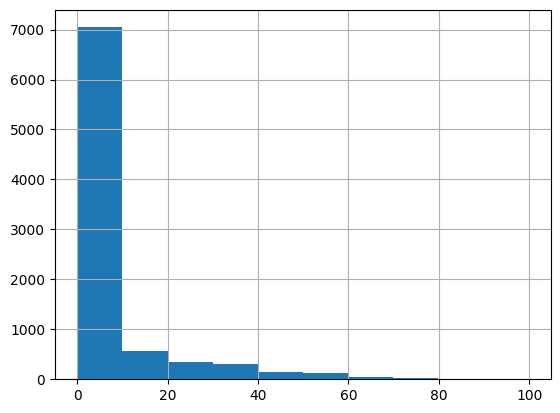

In [13]:
# histograma de Sugar_g


df["Sugar_g"].hist()

In [14]:

# calculo el skew de sugar_g

df["Sugar_g"].skew()

np.float64(2.953324419437816)

In [15]:
np.log(0+1)

np.float64(0.0)

In [16]:
np.log1p(0) # entiende qué hace log1p en lugar de log

np.float64(0.0)

In [20]:

# aplico una transformación logarítmica a todas las columnas numéricas para estabilizar la varianza (acercar outliers)

num_cols = df.select_dtypes(include="number").columns

df[num_cols] = np.log1p(df[num_cols])

df.head()

,FoodGroup,ShortDescrip,Descrip,CommonName,MfgName,ScientificName,Energy_kcal,Protein_g,Fat_g,Carb_g,...,Riboflavin_mg,Thiamin_mg,Calcium_mg,Copper_mcg,Iron_mg,Magnesium_mg,Manganese_mg,Phosphorus_mg,Selenium_mcg,Zinc_mg
ID,,,,,,,,,,,,,,,,,,,,,
1001,Dairy and Egg Products,"BUTTER,WITH SALT","Butter, salted",NaN,NaN,NaN,2.025047,0.479450,1.687890,0.056634,...,0.032888,0.004975,1.439569,0.000000,0.019609,0.741276,0.000000,1.439569,0.526589,0.082665
1002,Dairy and Egg Products,"BUTTER,WHIPPED,WITH SALT","Butter, whipped, with salt",NaN,NaN,NaN,2.025047,0.479450,1.687890,0.056634,...,0.032888,0.004975,1.439569,0.015749,0.138387,0.741276,0.003984,1.429846,0.526589,0.047637
1003,Dairy and Egg Products,"BUTTER OIL,ANHYDROUS","Butter oil, anhydrous",NaN,NaN,NaN,2.051107,0.220628,1.724543,0.000000,...,0.004975,0.000999,0.959135,0.000999,0.000000,0.000000,0.000000,0.869742,0.000000,0.009901
1004,Dairy and Egg Products,"CHEESE,BLUE","Cheese, blue",NaN,NaN,NaN,1.927062,1.413195,1.479897,0.791168,...,0.280304,0.028186,1.983892,0.038471,0.239038,1.429846,0.008920,1.940324,1.319310,0.831806
1005,Dairy and Egg Products,"CHEESE,BRICK","Cheese, brick",NaN,NaN,NaN,1.934256,1.432224,1.486956,0.846883,...,0.263014,0.013807,2.016863,0.023440,0.305773,1.439569,0.011858,1.962020,1.319310,0.824585


<Axes: >

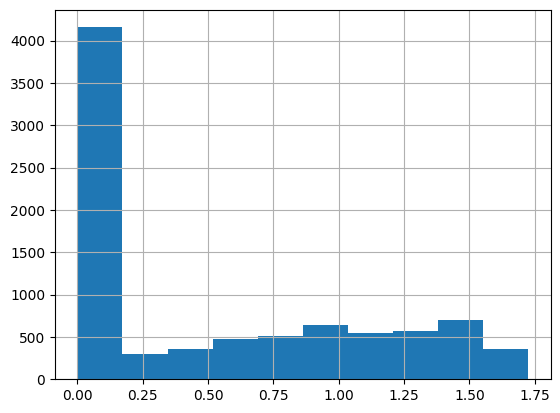

In [21]:

# histograma de Sugar_g

df["Sugar_g"].hist()

In [22]:

# asimetría (skew) de Sugar_g

df["Sugar_g"].skew()

np.float64(0.5464131149268806)

### Estandarizado
Estandariza cada variable.

No es necesario que dividas en train y test.

In [30]:

# StandardScaler con las columnas numéricas


num_cols = df.select_dtypes(include="number").columns

scaler = StandardScaler()

df_scaled = scaler.fit_transform(df[num_cols])


### Implementación del PCA
Prueba a montar un PCA con todos los componentes. Para ello utiliza los datos previamente transformados y escalados.

In [29]:
#shape del df

df_scaled.shape

(8618, 23)

In [31]:

# PCA con 23 componentes
# ajustado con el df escalado
# miro el shape

pca = PCA(n_components=23)

df_pca = pca.fit_transform(df_scaled)

df_pca.shape

(8618, 23)

### Aportación de cada PCA
Visualiza en un diagrama de líneas la suma acumulada de la varianza explicativa del PCA.

Si tuviéses que quedarte con 70-75 % de la varianza original, ¿con cuántos Principal Components te quedarías?

In [33]:
# varianza explicada de cada componente principal

pca.explained_variance_ratio_

array([0.32381018, 0.16347983, 0.08783905, 0.06475889, 0.05840121,
       0.04489496, 0.0297544 , 0.02652635, 0.02406082, 0.02378154,
       0.0228317 , 0.01833402, 0.01698111, 0.01406487, 0.01314262,
       0.01157939, 0.01110211, 0.00975687, 0.00859297, 0.00794686,
       0.00659335, 0.00624186, 0.00552501])

In [34]:

# varianza explicada acumulada
pca.explained_variance_ratio_.cumsum()

array([0.32381018, 0.48729002, 0.57512907, 0.63988796, 0.69828918,
       0.74318413, 0.77293853, 0.79946488, 0.8235257 , 0.84730724,
       0.87013894, 0.88847296, 0.90545408, 0.91951895, 0.93266157,
       0.94424096, 0.95534308, 0.96509995, 0.97369292, 0.98163978,
       0.98823313, 0.99447499, 1.        ])

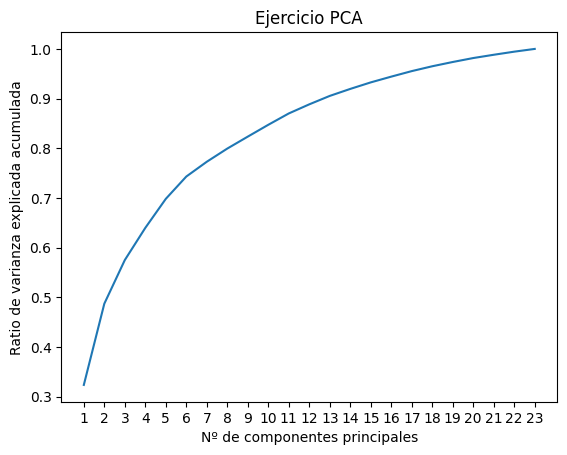

In [32]:
plt.plot(pd.Series(pca.explained_variance_ratio_.cumsum(), index=np.arange(1,24)))
plt.xlabel("Nº de componentes principales")
plt.ylabel("Ratio de varianza explicada acumulada")
plt.title("Ejercicio PCA")
plt.xticks(np.arange(1,24));

## Feat. Red
Crea un nuevo PCA con X Principal Components, siendo X la cantidad de PC escogidos en el apartado anterior.

Obtén el nuevo dataset con el mismo número de registros que el original, pero en este caso con X features, que representan los PC elegidos.

In [51]:

# con 6 componentes principales
# ajusto y transformo con la PCA
# miro el shape

pca6 = PCA(n_components=6)

X_pca6 = pca6.fit_transform(df_scaled)

df_pca.shape

(8618, 6)

In [52]:
df_pca6 = pd.DataFrame(X_pca6, columns=['PC1', 'PC2','PC3', 'PC4','PC5', 'PC6'])
df_pca6

,PC1,PC2,PC3,PC4,PC5,PC6
0,-2.132858,-1.478726,-0.136630,-1.002384,3.756908,0.602972
1,-2.067093,-1.379725,-0.076225,-1.026111,3.680115,0.656707
2,-3.821969,-1.881634,1.137434,-0.311557,3.813031,1.702231
3,1.593327,-1.297963,-1.039551,-0.605828,1.954047,-1.446671
4,1.165341,-1.222032,-1.062625,-0.969459,2.171133,-1.660302
...,...,...,...,...,...,...
8613,2.669732,-2.350600,-1.177254,-0.077560,2.488152,0.513880
8614,0.271258,-1.697508,-1.531053,-0.865871,-0.388078,-0.947058
8615,-3.201728,0.985864,1.118202,0.385917,-0.535378,-1.047394
8616,1.321902,-0.574167,-1.490190,-1.108449,1.524833,1.348070


In [53]:
df_pca6_origin = pd.DataFrame(pca6.components_, columns=df.select_dtypes(include="number").columns, index=['PC1', 'PC2','PC3', 'PC4','PC5', 'PC6'])
df_pca6_origin

,Energy_kcal,Protein_g,Fat_g,Carb_g,Sugar_g,Fiber_g,VitA_mcg,VitB6_mg,VitB12_mcg,VitC_mg,...,Riboflavin_mg,Thiamin_mg,Calcium_mg,Copper_mcg,Iron_mg,Magnesium_mg,Manganese_mg,Phosphorus_mg,Selenium_mcg,Zinc_mg
PC1,0.183006,0.293104,0.181272,-0.059334,-0.063696,0.019103,0.075865,0.259596,0.225635,-0.047336,...,0.259327,0.214394,0.157879,0.187285,0.274904,0.265919,0.117953,0.281460,0.264595,0.314497
PC2,0.006459,-0.153351,-0.155995,0.441721,0.320731,0.411931,0.099674,-0.007567,-0.258086,0.268684,...,0.066208,0.173528,0.187848,0.191302,0.114658,0.129026,0.319424,0.025875,-0.150447,-0.118396
PC3,0.421046,0.077515,0.359676,0.181244,0.218243,0.181111,-0.330938,-0.012251,-0.083349,-0.308076,...,0.098475,0.242790,-0.235121,-0.067570,0.163033,-0.213763,-0.024052,-0.148881,-0.166247,-0.026926
PC4,-0.180375,-0.146101,-0.187467,-0.022087,0.191688,-0.050941,0.168843,0.372232,0.270771,0.323300,...,0.386163,0.298403,-0.129017,-0.235550,0.070936,-0.183276,-0.304572,-0.160976,-0.156846,-0.034077
PC5,0.266000,-0.067988,0.352936,0.005464,0.240163,-0.123589,0.484179,-0.072027,0.067353,0.047493,...,-0.032472,-0.148526,0.116431,-0.121332,-0.175460,-0.055289,-0.163135,0.008811,0.108123,-0.068656
PC6,-0.094592,-0.180528,-0.005263,-0.213139,-0.222548,-0.040673,-0.141586,0.177379,0.029451,0.079801,...,-0.001870,0.010581,-0.352454,0.431663,0.007834,-0.180405,0.335096,-0.308409,0.008895,0.077899


### ¿Qué grupo de comida tiene los valores más altos en cada categoría?
Determina para cada Principal Component, los 3 grupos de comida (*FoodGroup*) con los valores del PC más altos.

In [54]:

# miro el value_counts de la columna FoodGroup

df['FoodGroup'].value_counts()

FoodGroup
Beef Products                          946
Vegetables and Vegetable Products      828
Baked Products                         797
Soups, Sauces, and Gravies             452
Lamb, Veal, and Game Products          438
Poultry Products                       390
Legumes and Legume Products            389
Fast Foods                             371
Breakfast Cereals                      363
Baby Foods                             362
Sweets                                 347
Fruits and Fruit Juices                346
Pork Products                          343
Beverages                              315
Finfish and Shellfish Products         267
Dairy and Egg Products                 264
Sausages and Luncheon Meats            244
Fats and Oils                          219
Cereal Grains and Pasta                183
Snacks                                 171
American Indian/Alaska Native Foods    165
Nut and Seed Products                  133
Meals, Entrees, and Side Dishes        113
R

In [55]:

# añado a la PCA una columna nueva FoodGroup que indica cada registro, cuál es su FoodGroup

df_pca6['FoodGroup'] = df['FoodGroup'].values
df_pca6

,PC1,PC2,PC3,PC4,PC5,PC6,FoodGroup
0,-2.132858,-1.478726,-0.136630,-1.002384,3.756908,0.602972,Dairy and Egg Products
1,-2.067093,-1.379725,-0.076225,-1.026111,3.680115,0.656707,Dairy and Egg Products
2,-3.821969,-1.881634,1.137434,-0.311557,3.813031,1.702231,Dairy and Egg Products
3,1.593327,-1.297963,-1.039551,-0.605828,1.954047,-1.446671,Dairy and Egg Products
4,1.165341,-1.222032,-1.062625,-0.969459,2.171133,-1.660302,Dairy and Egg Products
...,...,...,...,...,...,...,...
8613,2.669732,-2.350600,-1.177254,-0.077560,2.488152,0.513880,Finfish and Shellfish Products
8614,0.271258,-1.697508,-1.531053,-0.865871,-0.388078,-0.947058,Finfish and Shellfish Products
8615,-3.201728,0.985864,1.118202,0.385917,-0.535378,-1.047394,Sweets
8616,1.321902,-0.574167,-1.490190,-1.108449,1.524833,1.348070,Finfish and Shellfish Products


In [58]:

# agrupo por FoodGroup, calculo la media y ordeno por PC1 de forma descendente

df_pca6.groupby('FoodGroup').mean().sort_values("PC1", ascending=False)

,PC1,PC2,PC3,PC4,PC5,PC6
FoodGroup,,,,,,
Breakfast Cereals,3.226825,2.469990,1.137043,2.236892,-0.425691,-0.091089
Nut and Seed Products,2.648049,2.753384,0.508814,-1.907225,-0.498386,1.725991
Beef Products,2.078584,-2.612382,-0.210724,-0.016455,-0.192262,0.211393
"Lamb, Veal, and Game Products",1.842084,-2.453576,-0.044582,-0.080718,-0.373310,0.207026
Poultry Products,1.797705,-1.993724,-0.686995,0.040497,0.194906,-0.056734
Pork Products,1.769817,-1.984210,0.281278,0.429788,-0.268014,0.001600
Spices and Herbs,1.749693,3.353267,-0.369915,-0.777513,-0.728807,1.494346
Snacks,1.660615,2.044360,0.661049,-0.735282,0.477968,0.478838
Finfish and Shellfish Products,1.335487,-1.679770,-1.618287,-0.206059,0.458702,0.029080
